In [ ]:
# 1.模型选择
# 为了选择最佳模型，我们需要比较不同模型在训练数据和测试数据上的性能。
# 但是往往不能直接在测试集上评估模型的性能，因为这样可能会导致模型过拟合。
# 为了避免过拟合，我们通常会将数据集分为训练集、验证集和测试集。
# 训练集用于训练模型，验证集用于调整模型超参数，测试集用于最终评估模型性能。
# 但往往我们只能获得有限的数据集，因此需要合理划分数据集，以确保模型在训练集和测试集上都有良好的性能。常用的解决方案是K折交叉验证。
# 当训练数据稀缺时，我们甚至可能无法提供足够的数据来构成一个合适的验证集。 这个问题的一个流行的解决方案是采用K折交叉验证。 这里，原始训练数据被分成K个不重叠的子集。 然后执行K次模型训练和验证，每次在K-1个子集上进行训练， 并在剩余的一个子集（在该轮中没有用于训练的子集）上进行验证。 最后，通过对K次实验的结果取平均来估计训练和验证误差。

In [ ]:
# 2. 过拟合与欠拟合
# 过拟合与欠拟合是模型选择中常见的问题。
# 过拟合指的是模型在训练数据上的性能很好，但是在测试数据上的性能很差。
# 这通常是因为模型过于复杂，过度拟合了训练数据中的噪声和细节。
# 欠拟合指的是模型在训练数据上的性能很差，同时在测试数据上的性能也很差。
# 这通常是因为模型过于简单，无法捕捉到数据中的复杂模式。
# 为了避免过拟合和欠拟合，我们需要选择一个合适的模型复杂度。
# 通常，我们可以通过调整模型的超参数来实现这一点。
# 例如，我们可以增加模型的正则化参数来减少过拟合的风险，或者减少模型的复杂度来增加欠拟合的风险。
# 往往数据集的大小也会影响模型的性能。
# 如果数据集非常小，那么模型可能会过拟合。
# 因此，在选择模型时，我们需要考虑数据集的大小和模型的复杂度之间的平衡。

In [1]:
# 示例：多项式回归
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
max_degree = 20  # 多项式的最大阶数
n_train, n_test = 100, 100  # 训练和测试数据集大小
true_w = np.zeros(max_degree)  # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # gamma(n)=(n-1)!
# labels的维度:(n_train+n_test,)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

In [3]:
# NumPy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=
    torch.float32) for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.0572],
         [ 1.9996]]),
 tensor([[ 1.0000e+00, -5.7163e-02,  1.6338e-03, -3.1131e-05,  4.4488e-07,
          -5.0861e-09,  4.8456e-11, -3.9570e-13,  2.8274e-15, -1.7958e-17,
           1.0265e-19, -5.3346e-22,  2.5412e-24, -1.1174e-26,  4.5623e-29,
          -1.7386e-31,  6.2116e-34, -2.0887e-36,  6.6330e-39, -1.9956e-41],
         [ 1.0000e+00,  1.9996e+00,  1.9991e+00,  1.3325e+00,  6.6609e-01,
           2.6638e-01,  8.8773e-02,  2.5358e-02,  6.3382e-03,  1.4082e-03,
           2.8157e-04,  5.1184e-05,  8.5289e-06,  1.3118e-06,  1.8737e-07,
           2.4977e-08,  3.1214e-09,  3.6715e-10,  4.0785e-11,  4.2922e-12]]),
 tensor([4.7565, 8.1660]))

In [4]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [5]:
def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

weight: [[ 4.9873905  1.2232226 -3.4047084  5.5537605]]


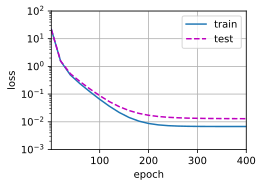

In [ ]:
# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
# 正常拟合
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

weight: [[3.425695 3.722361]]


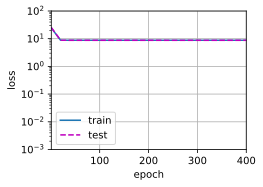

In [ ]:
# 从多项式特征中选择前2个维度，即1和x
# 欠拟合，误差较大
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

weight: [[ 4.9790907   1.27568    -3.3480585   5.2157083  -0.15100701  1.0314296
   0.16051108 -0.0846853  -0.19025563  0.05803076  0.01122154  0.04425843
  -0.00713888  0.06395364  0.03128769 -0.04185707  0.1870715   0.11632955
   0.09807426  0.17211238]]


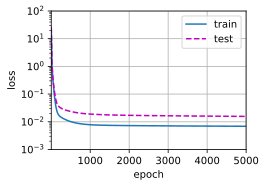

In [14]:
# 从多项式特征中选取所有维度
# 过拟合，误差较小
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=5000)